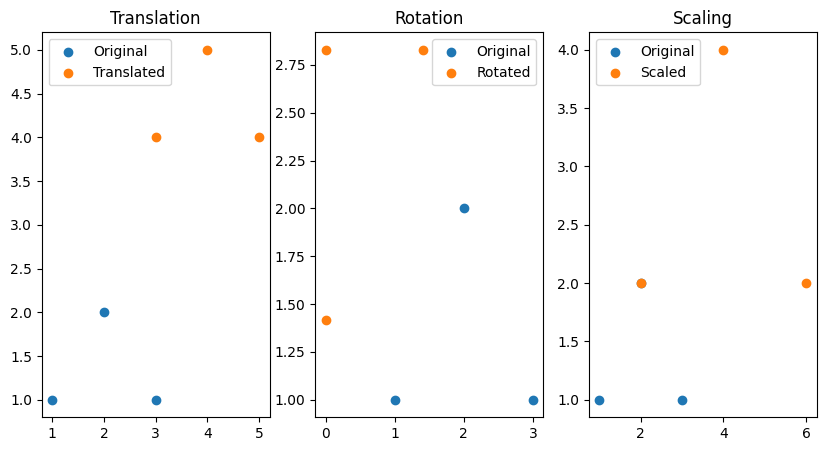

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([[1,1],[2,2],[3,1]])

# Translation
translation_matrix = np.array([[1,0,2],[0,1,3],[0,0,1]])
translated = np.dot(translation_matrix, np.hstack([points, np.ones((3,1))]).T).T[:,:2]

# Rotation
theta = np.pi/4
rotation_matrix = np.array([[np.cos(theta),-np.sin(theta),0],
                            [np.sin(theta),np.cos(theta),0],
                            [0,0,1]])
rotated = np.dot(rotation_matrix, np.hstack([points, np.ones((3,1))]).T).T[:,:2]

# Scaling
scaling_matrix = np.array([[2,0,0],[0,2,0],[0,0,1]])
scaled = np.dot(scaling_matrix, np.hstack([points, np.ones((3,1))]).T).T[:,:2]

# 🔥 Subplots (IMPORTANT)
plt.figure(figsize=(10,5))

# Translation
plt.subplot(1,3,1)
plt.title("Translation")
plt.scatter(points[:,0], points[:,1], label="Original")
plt.scatter(translated[:,0], translated[:,1], label="Translated")
plt.legend()

# Rotation
plt.subplot(1,3,2)
plt.title("Rotation")
plt.scatter(points[:,0], points[:,1], label="Original")
plt.scatter(rotated[:,0], rotated[:,1], label="Rotated")
plt.legend()

# Scaling
plt.subplot(1,3,3)
plt.title("Scaling")
plt.scatter(points[:,0], points[:,1], label="Original")
plt.scatter(scaled[:,0], scaled[:,1], label="Scaled")
plt.legend()

plt.show()

Image 1 shape: (545, 720, 3)
Image 2 shape: (545, 720, 3)
Number of points in points1: 233
Number of points in points2: 233


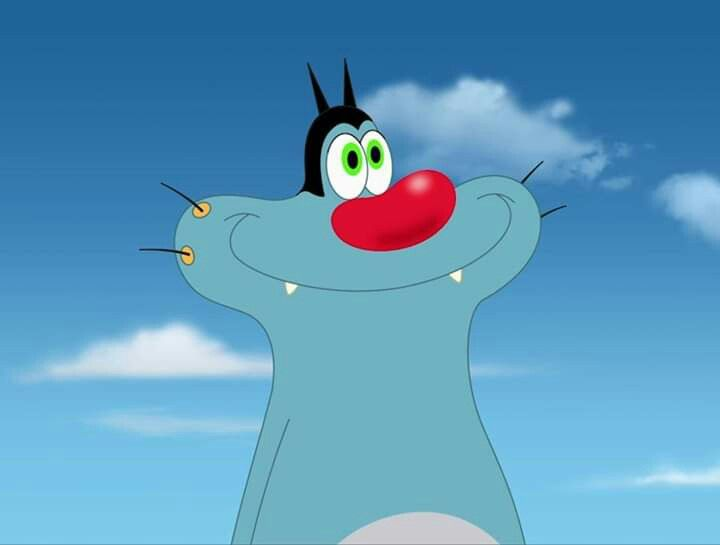

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

image1 = cv2.imread("/content/sample_data/oggy.jpg")
image2 = cv2.imread("/content/sample_data/oggy.jpg")

# ✅ PRINT (IMPORTANT)
print("Image 1 shape:", image1.shape)
print("Image 2 shape:", image2.shape)

gray1 = cv2.cvtColor(image1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

bf = cv2.BFMatcher()
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1,1,2)
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1,1,2)

# ✅ PRINT POINTS COUNT
print("Number of points in points1:", len(pts1))
print("Number of points in points2:", len(pts2))

H, _ = cv2.findHomography(pts1, pts2, cv2.RANSAC)

h, w = image2.shape[:2]
stitched = cv2.warpPerspective(image1, H, (w, h))

stitched[0:image2.shape[0], 0:image2.shape[1]] = image2

cv2_imshow(stitched)

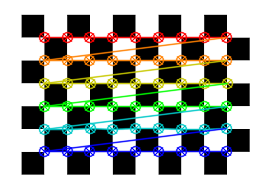

Camera matrix:
[[1.03955481e+03 0.00000000e+00 1.53881193e+02]
 [0.00000000e+00 1.04145168e+03 6.82307367e+01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:
[[ 1.18151099e+00 -9.65976028e+01  1.24794627e-03 -3.27170233e-03
   2.52382257e+03]]


In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Chessboard size
nx, ny = 9, 6

# Prepare object points
objp = np.zeros((nx*ny,3), np.float32)
objp[:,:2] = np.mgrid[0:nx,0:ny].T.reshape(-1,2)

objpoints = []
imgpoints = []

# Load image
img = cv2.imread("/content/sample_data/calib.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find corners
ret, corners = cv2.findChessboardCorners(gray, (nx, ny), None)

if ret:
    objpoints.append(objp)
    imgpoints.append(corners)

    # Draw corners (same mam output)
    cv2.drawChessboardCorners(img, (nx, ny), corners, ret)
    cv2_imshow(img)

# Calibration
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

print("Camera matrix:")
print(mtx)

print("\nDistortion coefficients:")
print(dist)

In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg

--2026-03-30 15:54:19--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/left01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 27908 (27K) [image/jpeg]
Saving to: ‘left01.jpg’

left01.jpg          100%[===================>]  27.25K  --.-KB/s    in 0s      

2026-03-30 15:54:19 (93.2 MB/s) - ‘left01.jpg’ saved [27908/27908]



In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Chessboard size
nx, ny = 9, 6

# Prepare object points
objp = np.zeros((nx*ny,3), np.float32)
objp[:,:2] = np.mgrid[0:nx,0:ny].T.reshape(-1,2)

objpoints = []
imgpoints = []

# Load image
img = cv2.imread("left01.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find corners
ret, corners = cv2.findChessboardCorners(gray, (nx, ny), None)

if ret:
    objpoints.append(objp)
    imgpoints.append(corners)

    # Draw corners (same mam output)
    cv2.drawChessboardCorners(img, (nx, ny), corners, ret)
    cv2_imshow(img)

# Calibration
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(
    objpoints, imgpoints, gray.shape[::-1], None, None
)

print("Camera matrix:")
print(mtx)

print("\nDistortion coefficients:")
print(dist)

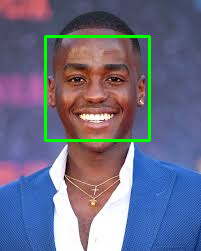

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Load image (change filename if needed)
image = cv2.imread("/content/sample_data/eric.jfif")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect faces (tuned for single correct box)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.2,
    minNeighbors=7,
    minSize=(30, 30)
)

# Draw rectangle (only main face)
for (x, y, w, h) in faces[:1]:   # 👈 only first detection
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Print number of faces


# Show output
cv2_imshow(image)

In [ ]:
!pip install tensorflow

In [ ]:
# Model download
!wget http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v2_coco_2018_03_29.tar.gz
!tar -xvf ssd_mobilenet_v2_coco_2018_03_29.tar.gz

# Label file
!wget https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/data/mscoco_label_map.pbtxt

# Sample image
!wget https://ultralytics.com/images/bus.jpg

--2026-03-31 08:08:55--  http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v2_coco_2018_03_29.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 192.178.219.207, 173.194.215.207, 173.194.216.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|192.178.219.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 187925923 (179M) [application/x-tar]
Saving to: ‘ssd_mobilenet_v2_coco_2018_03_29.tar.gz’

ssd_mobilenet_v2_co 100%[===================>] 179.22M   387MB/s    in 0.5s    

2026-03-31 08:08:55 (387 MB/s) - ‘ssd_mobilenet_v2_coco_2018_03_29.tar.gz’ saved [187925923/187925923]

ssd_mobilenet_v2_coco_2018_03_29/checkpoint
ssd_mobilenet_v2_coco_2018_03_29/model.ckpt.meta
ssd_mobilenet_v2_coco_2018_03_29/pipeline.config
ssd_mobilenet_v2_coco_2018_03_29/saved_model/saved_model.pb
ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb
ssd_mobilenet_v2_coco_2018_03_29/saved_model/
ssd_mobilenet_v2_coco_2018

In [ ]:
!wget http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v2_coco_2018_03_29.tar.gz
!tar -xvf ssd_mobilenet_v2_coco_2018_03_29.tar.gz

--2026-04-01 03:12:13--  http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v2_coco_2018_03_29.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 172.217.218.207, 142.251.31.207, 142.251.18.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|172.217.218.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 187925923 (179M) [application/x-tar]
Saving to: ‘ssd_mobilenet_v2_coco_2018_03_29.tar.gz’

ssd_mobilenet_v2_co 100%[===================>] 179.22M  42.2MB/s    in 5.0s    

2026-04-01 03:12:18 (36.1 MB/s) - ‘ssd_mobilenet_v2_coco_2018_03_29.tar.gz’ saved [187925923/187925923]

ssd_mobilenet_v2_coco_2018_03_29/checkpoint
ssd_mobilenet_v2_coco_2018_03_29/model.ckpt.meta
ssd_mobilenet_v2_coco_2018_03_29/pipeline.config
ssd_mobilenet_v2_coco_2018_03_29/saved_model/saved_model.pb
ssd_mobilenet_v2_coco_2018_03_29/frozen_inference_graph.pb
ssd_mobilenet_v2_coco_2018_03_29/saved_model/
ssd_mobilenet_v2_coco_2018_

Detected objects:
person (0.84)
object (0.67)
object (0.53)
object (0.52)


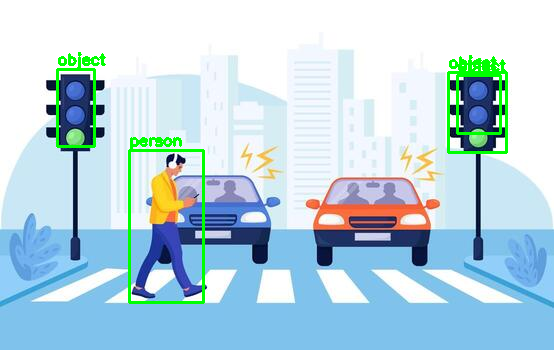

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
from google.colab.patches import cv2_imshow

MODEL_NAME = 'ssd_mobilenet_v2_coco_2018_03_29'
PATH_TO_CKPT = MODEL_NAME + '/frozen_inference_graph.pb'

detection_graph = tf.Graph()

with detection_graph.as_default():
    od_graph_def = tf.compat.v1.GraphDef()
    with tf.io.gfile.GFile(PATH_TO_CKPT, 'rb') as fid:
        od_graph_def.ParseFromString(fid.read())
        tf.import_graph_def(od_graph_def, name='')

category_index = {
    1: 'person',
    2: 'bicycle',
    3: 'car',
    6: 'bus'
}

image = cv2.imread("/content/sample_data/obj1.jpg")

with detection_graph.as_default():
    with tf.compat.v1.Session(graph=detection_graph) as sess:

        image_expanded = np.expand_dims(image, axis=0)

        image_tensor = detection_graph.get_tensor_by_name('image_tensor:0')
        boxes = detection_graph.get_tensor_by_name('detection_boxes:0')
        scores = detection_graph.get_tensor_by_name('detection_scores:0')
        classes = detection_graph.get_tensor_by_name('detection_classes:0')

        (boxes, scores, classes) = sess.run(
            [boxes, scores, classes],
            feed_dict={image_tensor: image_expanded}
        )

print("Detected objects:")

for i in range(len(scores[0])):
    if scores[0][i] > 0.5:

        ymin, xmin, ymax, xmax = boxes[0][i]
        (h, w, _) = image.shape

        left = int(xmin * w)
        right = int(xmax * w)
        top = int(ymin * h)
        bottom = int(ymax * h)

        class_id = int(classes[0][i])
        label = category_index.get(class_id, "object")
        confidence = scores[0][i]

        # 🔥 PRINT (same as friend)
        print(f"{label} ({confidence:.2f})")

        # Draw box
        cv2.rectangle(image, (left, top), (right, bottom), (0,255,0), 2)
        cv2.putText(image, label, (left, top-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)

cv2_imshow(image)

In [ ]:
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/data/pedestrian.png -O pedestrian.jpg

--2026-03-31 08:37:26--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/pedestrian.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-31 08:37:26 ERROR 404: Not Found.



Image loaded ✅
Pedestrians detected: 2


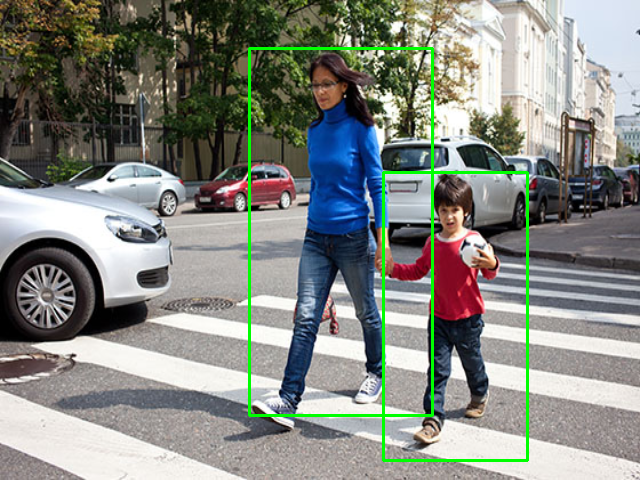

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

# 📂 Load image (manual upload)
image = cv2.imread("/content/sample_data/pede.jpg")

# ✅ Check image
if image is None:
    print("Image not found ❌ Check file name/path")
else:
    print("Image loaded ✅")

# Resize (important)
image = cv2.resize(image, (640, 480))

# HOG Detector
hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

# Detect pedestrians
boxes, weights = hog.detectMultiScale(
    image,
    winStride=(8,8),
    padding=(8,8),
    scale=1.03   # 👈 better detection
)

# Print result (friend style)
print("Pedestrians detected:", len(boxes))

# Draw boxes
for (x, y, w, h) in boxes:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0,255,0), 2)

# Show output
cv2_imshow(image)

Inliers: 82
Outliers: 18


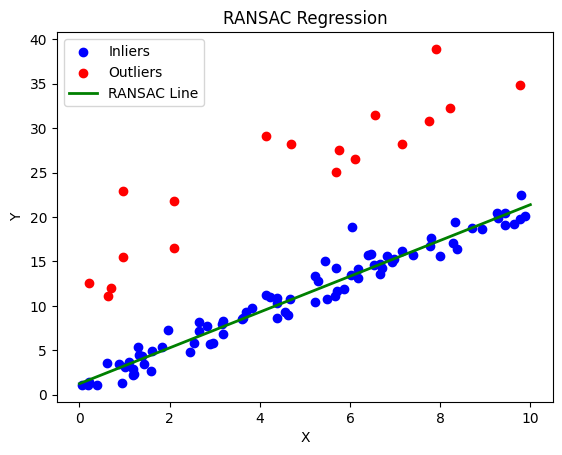

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# Generate random data
np.random.seed(0)

X = np.random.uniform(0, 10, 100)
y = 2 * X + 1 + np.random.normal(0, 1, 100)

# Add outliers
outliers = np.random.choice(100, 20, replace=False)
y[outliers] += np.random.normal(15, 5, 20)

# Reshape for model
X = X.reshape(-1, 1)

# Apply RANSAC
ransac = RANSACRegressor()
ransac.fit(X, y)

# Predict line
line_X = np.linspace(0, 10, 100).reshape(-1, 1)
line_y = ransac.predict(line_X)

# Inliers & Outliers
inlier_mask = ransac.inlier_mask_
outlier_mask = np.logical_not(inlier_mask)

# Print (friend style terminal output)
print("Inliers:", np.sum(inlier_mask))
print("Outliers:", np.sum(outlier_mask))

# Plot
plt.scatter(X[inlier_mask], y[inlier_mask], color='blue', label='Inliers')
plt.scatter(X[outlier_mask], y[outlier_mask], color='red', label='Outliers')
plt.plot(line_X, line_y, color='green', linewidth=2, label='RANSAC Line')

plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("RANSAC Regression")

plt.show()

Image loaded ✅


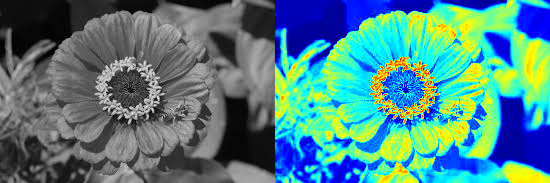

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load grayscale flower image
image = cv2.imread("/content/sample_data/flower.jfif", cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Image not found ❌")
else:
    print("Image loaded ✅")

# Apply color map
colored = cv2.applyColorMap(image, cv2.COLORMAP_JET)

# Convert gray to BGR for side-by-side
gray_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

# Combine horizontally
combined = np.hstack((gray_bgr, colored))

# Show
cv2_imshow(combined)

Images loaded ✅


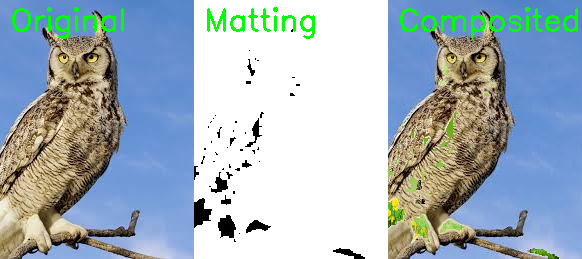

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load images (same folder me hone chahiye)
image = cv2.imread("/content/sample_data/owl.jfif")
background = cv2.imread("/content/sample_data/bg.jpg")

# Check
if image is None or background is None:
    print("Image not loaded ❌")
    exit()
else:
    print("Images loaded ✅")

# Resize background same size
background = cv2.resize(background, (image.shape[1], image.shape[0]))

# ---------------------------
# STEP 1: MATTING (Mask)
# ---------------------------

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Threshold (adjust if needed)
_, mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

# Clean mask
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_DILATE, kernel)

# ---------------------------
# STEP 2: COMPOSITING
# ---------------------------

mask_inv = cv2.bitwise_not(mask)

fg = cv2.bitwise_and(image, image, mask=mask)
bg = cv2.bitwise_and(background, background, mask=mask_inv)

final = cv2.add(fg, bg)

# ---------------------------
# STEP 3: HORIZONTAL OUTPUT
# ---------------------------

# Convert mask to 3-channel
mask_color = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

# Resize all same size
h, w = image.shape[:2]
mask_color = cv2.resize(mask_color, (w, h))
final = cv2.resize(final, (w, h))

# Add labels
cv2.putText(image, "Original", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

cv2.putText(mask_color, "Matting", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

cv2.putText(final, "Composited", (10,30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

# Combine horizontally
combined = np.hstack((image, mask_color, final))

# Show result
cv2_imshow(combined)

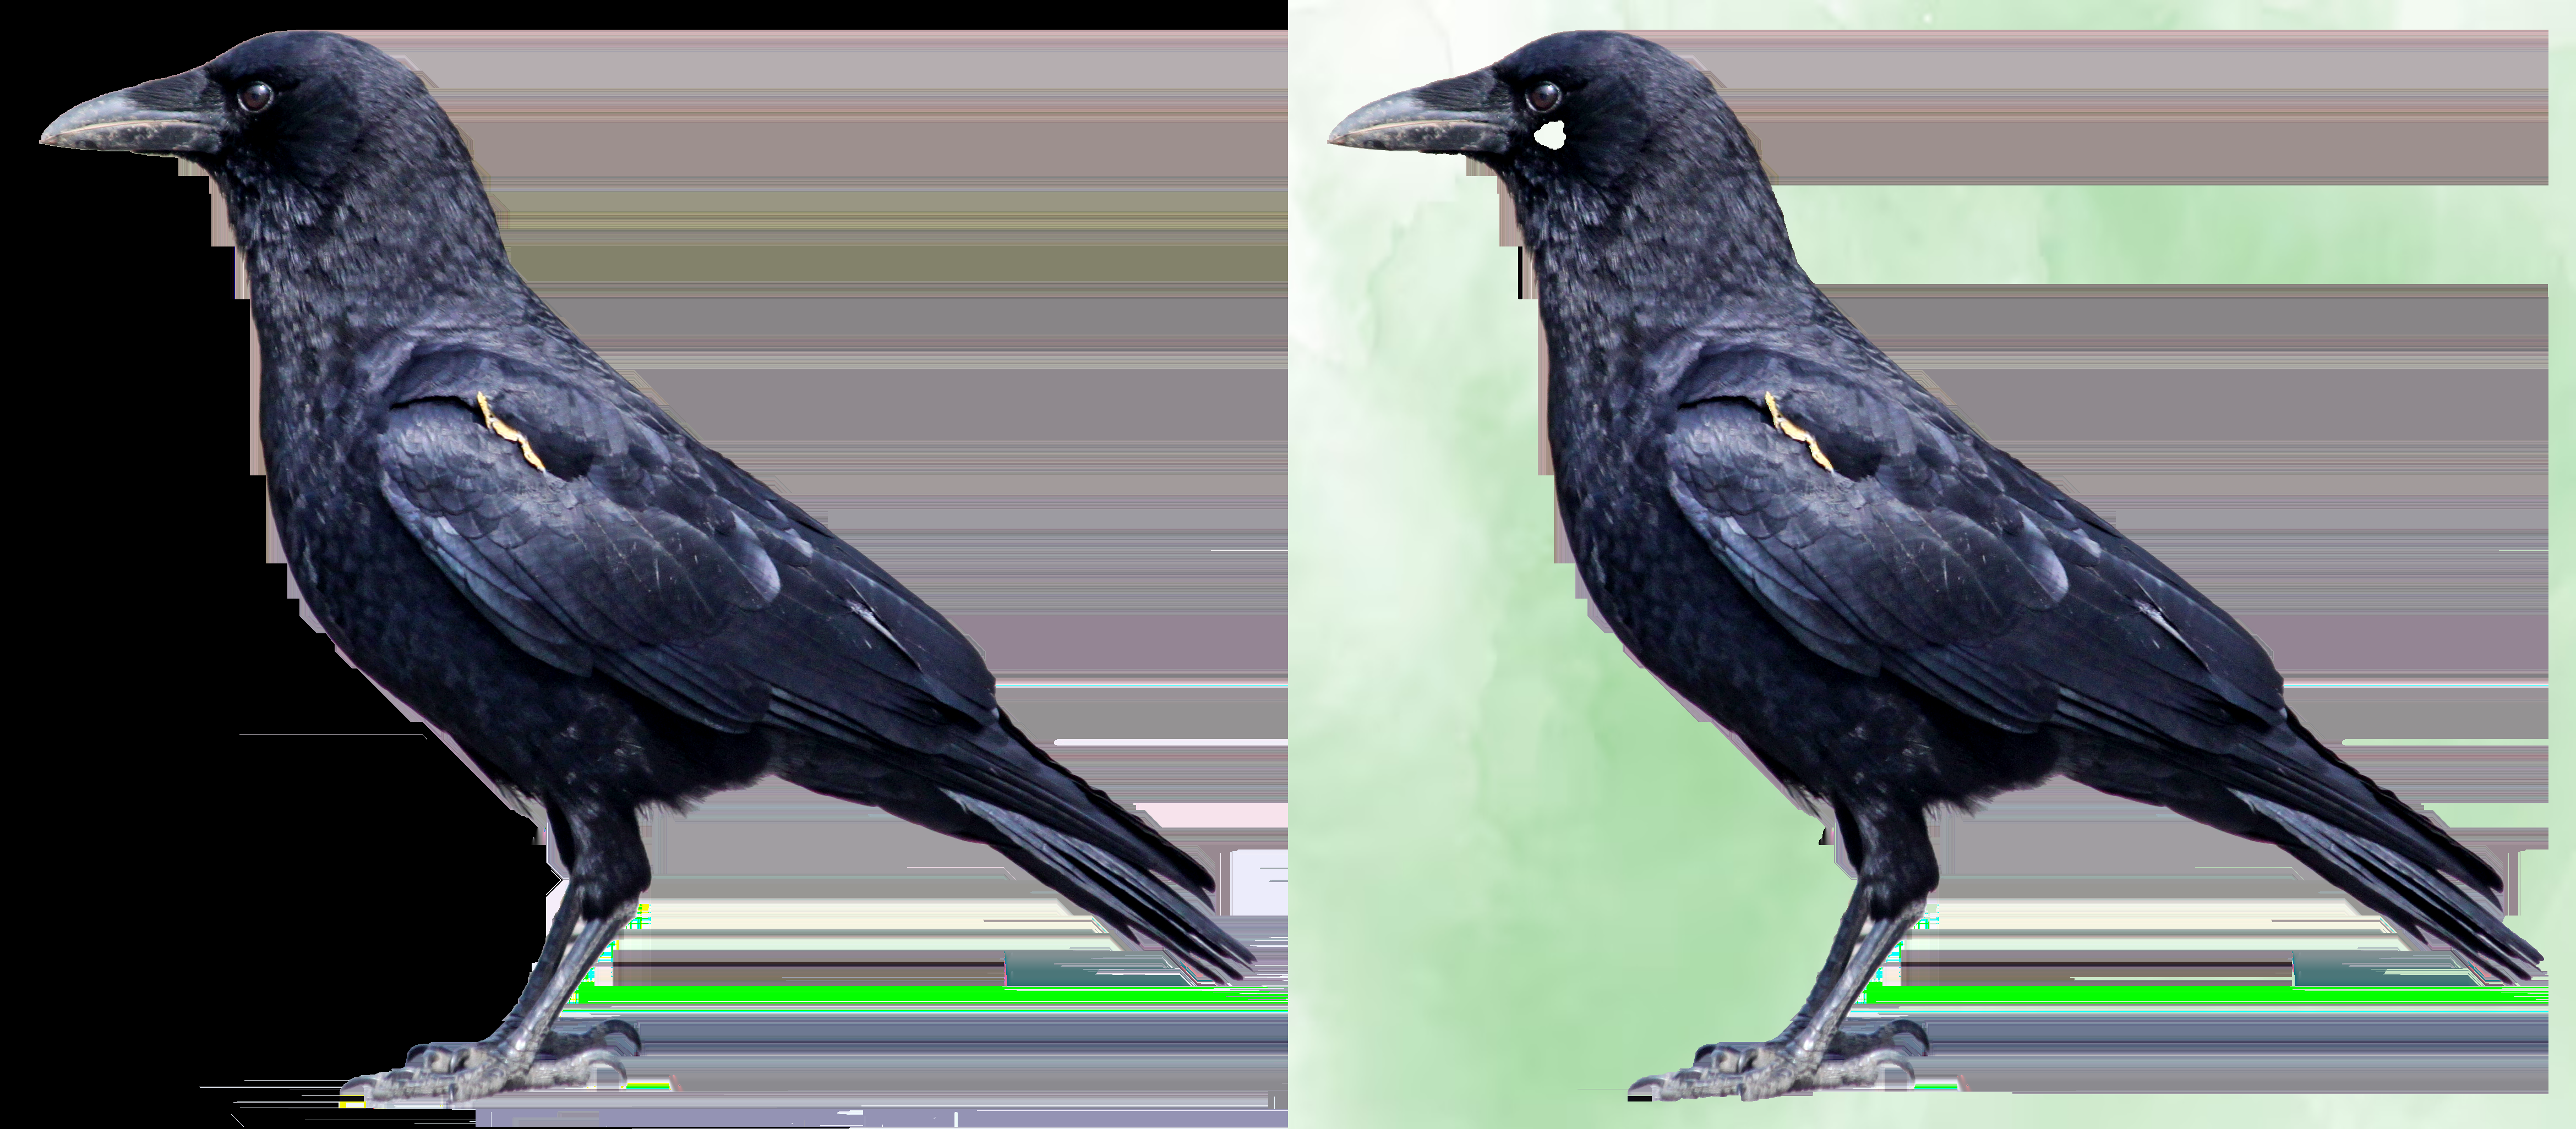

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load images
image = cv2.imread("/content/sample_data/cr.png")
background = cv2.imread("/content/sample_data/bgg.avif")

# Resize background
background = cv2.resize(background, (image.shape[1], image.shape[0]))

# Create mask for GrabCut
mask = np.zeros(image.shape[:2], np.uint8)

# Temporary arrays
bgdModel = np.zeros((1,65), np.float64)
fgdModel = np.zeros((1,65), np.float64)

# Rectangle (object area approx)
rect = (50, 50, image.shape[1]-100, image.shape[0]-100)

# Apply GrabCut
cv2.grabCut(image, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Final mask
mask2 = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')

# Extract foreground
fg = image * mask2[:,:,np.newaxis]

# Extract background
bg = background * (1 - mask2[:,:,np.newaxis])

# Combine
final = fg + bg

# Show side-by-side
combined = np.hstack((image, final))
cv2_imshow(combined)